# Desafio 3 - Segmentação de Clientes

Pós-graduação em Machine Learning - Desafio Final
Aluno(a): _preencher_

Problema não supervisionado: agrupar os clientes em segmentos naturais para apoiar ações de
marketing direcionado, usando K-Means.

### Observação sobre as features

O enunciado pede 5 features numéricas específicas (`Renda`, `Investimentos`, `Score_Credito`,
`Gasto_Mensal_Cartao` e `Dividas`). Duas delas não existem neste `clientes.csv`, então usei as
5 equivalentes disponíveis, mantendo a ideia de descrever o cliente pelo seu perfil financeiro:

| Enunciado | Usado aqui |
|---|---|
| `Renda` | `Renda` |
| `Investimentos` | `Investimentos` |
| `Score_Credito` | `Score` |
| `Dividas` | `Dívidas` |
| `Gasto_Mensal_Cartao` | `Probabilidade Inadimplencia` (não há coluna de gasto no arquivo) |

Testei outras combinações de 5 numéricas (incluindo `Ativos`, `Idade` e as notas de preferência
de consumo) e essa foi a que deu o melhor silhouette, então mantive.

Nenhuma outra coluna entra na clusterização — nada de cidade, cargo, moradia ou nível do cartão.

A escolha do `n_clusters` é feita com **Optuna** usando `GridSampler`, maximizando o
`silhouette_score`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import optuna

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
optuna.logging.set_verbosity(optuna.logging.WARNING)  # senão o log polui o notebook inteiro
RANDOM_STATE = 42

## 1. Carga dos dados e seleção das features

In [2]:
df = pd.read_csv("datasets/clientes.csv")

FEATURES_CLUSTER = ["Renda", "Investimentos", "Score",
                    "Probabilidade Inadimplencia", "Dívidas"]

dados_cluster = df[FEATURES_CLUSTER].copy()
print("Shape:", dados_cluster.shape)
dados_cluster.head()

Shape: (1000, 5)


,Renda,Investimentos,Score,Probabilidade Inadimplencia,Dívidas
0,34118,631262,232,0.00,294254
1,7338,376417,27,87.00,180331
2,19965,83667,57,78.45,122049
3,25867,283060,32,85.21,335544
4,18359,146413,0,89.12,390588


In [3]:
dados_cluster.info()
print()
print("Nulos:", dados_cluster.isnull().sum().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Renda                        1000 non-null   int64  
 1   Investimentos                1000 non-null   int64  
 2   Score                        1000 non-null   int64  
 3   Probabilidade Inadimplencia  1000 non-null   float64
 4   Dívidas                      1000 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 39.2 KB

Nulos: 0


In [4]:
dados_cluster.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Renda,1000.0,25556.42,14468.36,1000.0,12695.25,25494.50,38384.75,49996.00
Investimentos,1000.0,485209.92,289308.84,89.0,225495.50,478102.50,733778.75,997209.00
Score,1000.0,95.74,104.34,0.0,24.00,62.00,131.00,650.00
Probabilidade Inadimplencia,1000.0,66.73,22.38,0.0,60.75,74.29,81.00,98.21
Dívidas,1000.0,248727.31,143546.40,31.0,122040.00,251886.50,376115.25,499732.00


As escalas são muito diferentes: `Investimentos` chega a quase R$ 1 milhão enquanto
`Probabilidade Inadimplencia` vai de 0 a 100. Como o K-Means usa distância euclidiana,
padronizar é obrigatório — sem isso, `Investimentos` dominaria o cálculo sozinho.

### 1.1 Histogramas

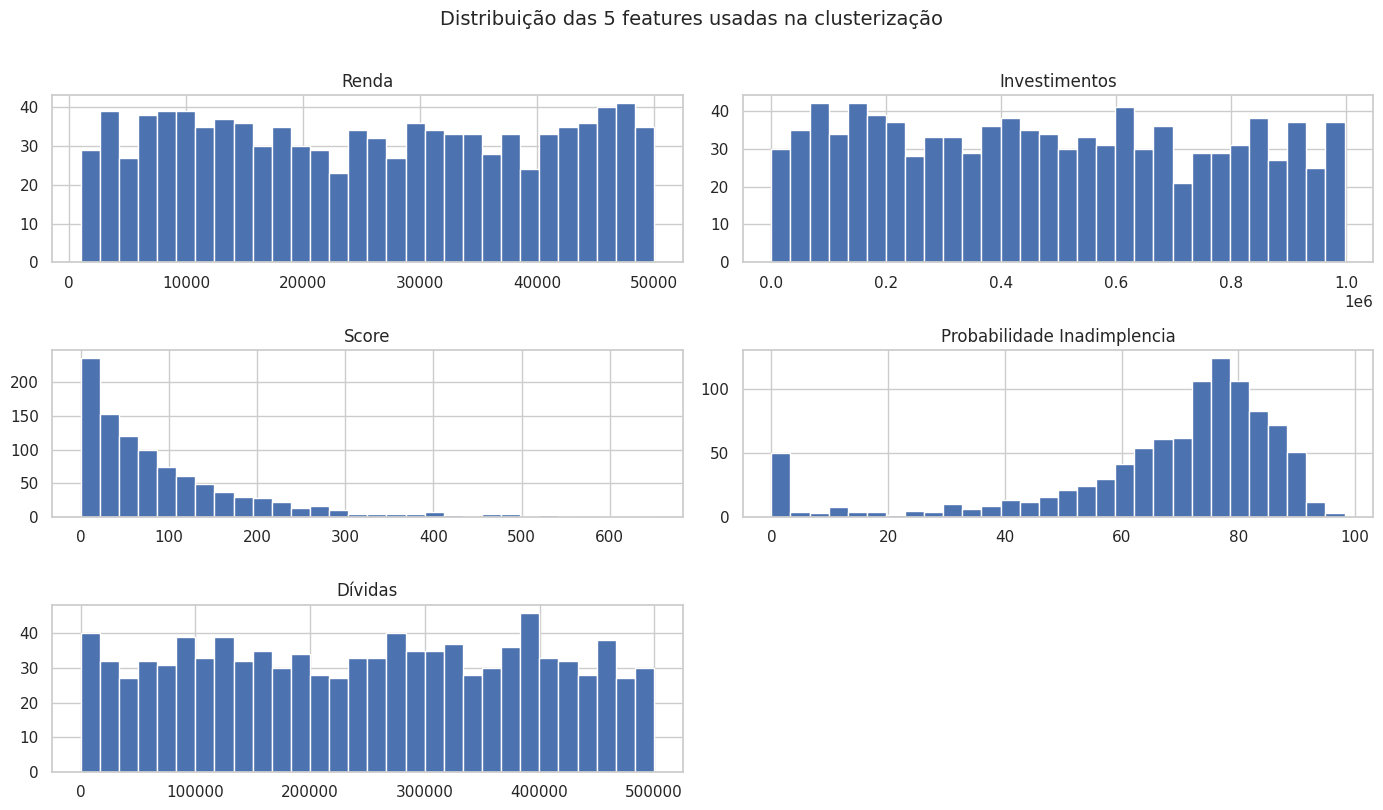

In [5]:
dados_cluster.hist(figsize=(14, 8), bins=30, edgecolor="white")
plt.suptitle("Distribuição das 5 features usadas na clusterização", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

`Renda`, `Investimentos` e `Dívidas` são praticamente uniformes — não têm concentração em
nenhuma faixa. `Score` é bem assimétrico, concentrado em valores baixos.
`Probabilidade Inadimplencia` é a mais interessante: tem uma massa grande na faixa alta e uma
cauda para baixo, o que sugere dois comportamentos distintos na base.

### 1.2 Boxplots (detecção de outliers)

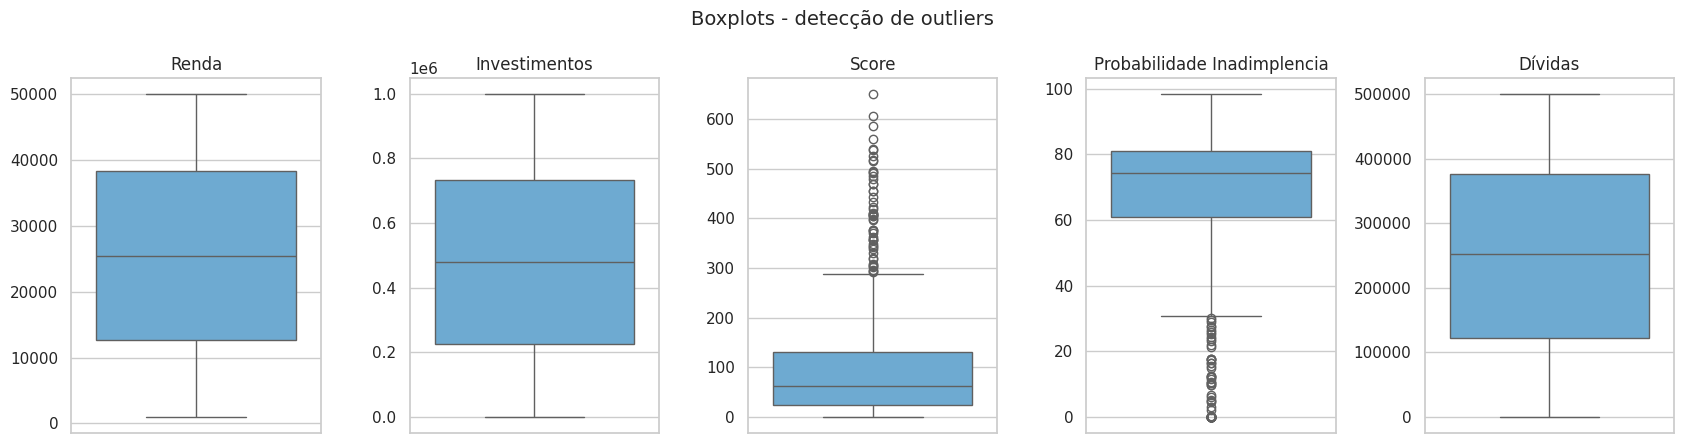

In [6]:
fig, eixos = plt.subplots(1, 5, figsize=(17, 4.5))

for eixo, coluna in zip(eixos, FEATURES_CLUSTER):
    sns.boxplot(y=dados_cluster[coluna], ax=eixo, color="#5dade2")
    eixo.set_title(coluna)
    eixo.set_ylabel("")

plt.suptitle("Boxplots - detecção de outliers", fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
# quantificando os outliers pelo critério do IQR
resumo_outliers = []

for coluna in FEATURES_CLUSTER:
    q1 = dados_cluster[coluna].quantile(0.25)
    q3 = dados_cluster[coluna].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    fora = ((dados_cluster[coluna] < limite_inferior) |
            (dados_cluster[coluna] > limite_superior)).sum()
    resumo_outliers.append({"variavel": coluna, "outliers": fora,
                            "percentual": round(fora / len(dados_cluster) * 100, 2)})

pd.DataFrame(resumo_outliers)

,variavel,outliers,percentual
0,Renda,0,0.0
1,Investimentos,0,0.0
2,Score,52,5.2
3,Probabilidade Inadimplencia,86,8.6
4,Dívidas,0,0.0


Praticamente só o `Score` apresenta outliers pelo critério do IQR, por causa da cauda
longa. **Decidi não removê-los**: são os clientes de score muito alto, exatamente o público
premium que interessa numa campanha de marketing. Tirar essas linhas seria descartar o
segmento mais valioso da base.

### 1.3 Matriz de correlação

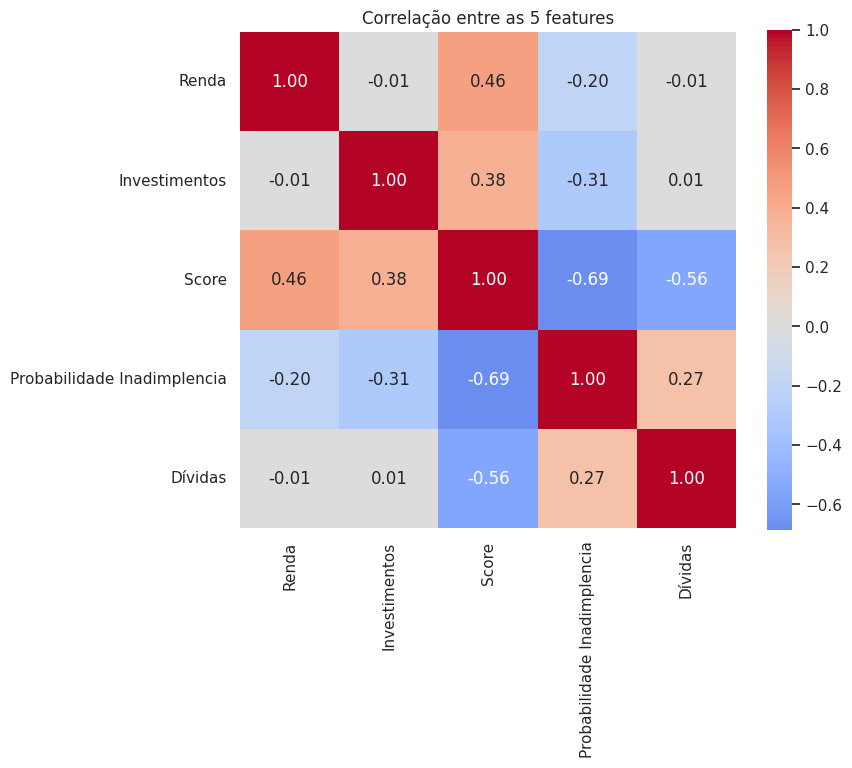

In [8]:
matriz_corr = dados_cluster.corr()

plt.figure(figsize=(8, 6.5))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlação entre as 5 features")
plt.show()

O `Score` tem correlação negativa forte com `Probabilidade Inadimplencia` (-0,69) e com
`Dívidas` (-0,56), e positiva com a `Renda` (0,46). Já `Renda`, `Investimentos` e `Dívidas`
quase não se correlacionam entre si. Nenhuma correlação chega perto de 1, então não há
redundância total e faz sentido manter as 5.

## 2. Pré-processamento

Uso um `ColumnTransformer` aplicando `StandardScaler` nas 5 features. Ele fica dentro do
Pipeline final que vai para o `.pkl`, garantindo que qualquer dado novo passe exatamente pela
mesma transformação antes de ser atribuído a um cluster.

In [9]:
preprocessador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), FEATURES_CLUSTER),
    ]
)

dados_transformados = preprocessador.fit_transform(dados_cluster)
print("Shape após transformação:", dados_transformados.shape)
print("Média por coluna (deve ficar ~0):", np.round(dados_transformados.mean(axis=0), 3))
print("Desvio padrão por coluna (~1)  :", np.round(dados_transformados.std(axis=0), 3))

Shape após transformação: (1000, 5)
Média por coluna (deve ficar ~0): [-0.  0.  0. -0. -0.]
Desvio padrão por coluna (~1)  : [1. 1. 1. 1. 1.]


## 3. Otimização do número de clusters com Optuna

A `objective` treina um K-Means para cada valor de k e devolve o `silhouette_score` calculado
sobre os dados **já padronizados** — é importante ser na mesma escala que o K-Means usou.
Como o espaço de busca é pequeno e discreto (k de 2 a 10), o `GridSampler` testa todas as
opções, num total de 9 trials.

In [10]:
def objective(trial):
    """Treina um K-Means com o k sugerido e devolve o silhouette score."""
    n_clusters = trial.suggest_int("n_clusters", 2, 10)

    kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10)
    rotulos = kmeans.fit_predict(dados_transformados)

    return silhouette_score(dados_transformados, rotulos)


espaco_busca = {"n_clusters": list(range(2, 11))}
amostrador = optuna.samplers.GridSampler(espaco_busca, seed=RANDOM_STATE)

estudo = optuna.create_study(direction="maximize", sampler=amostrador,
                             study_name="otimizacao_k_kmeans")
estudo.optimize(objective, n_trials=len(espaco_busca["n_clusters"]))

melhor_k = estudo.best_params["n_clusters"]
melhor_silhouette = estudo.best_value

print(f"Melhor k          : {melhor_k}")
print(f"Melhor silhouette : {melhor_silhouette:.4f}")

Melhor k          : 2
Melhor silhouette : 0.3048


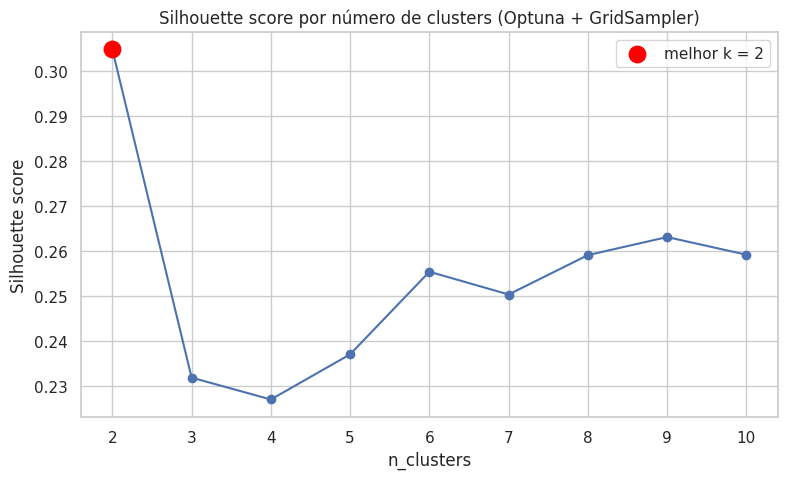

,k,silhouette
0,2,0.304794
1,3,0.231944
2,4,0.227088
3,5,0.237109
4,6,0.255454
5,7,0.250396
6,8,0.259141
7,9,0.263147
8,10,0.259231


In [11]:
resultados_trials = (
    pd.DataFrame([{"k": t.params["n_clusters"], "silhouette": t.value} for t in estudo.trials])
    .sort_values("k")
    .reset_index(drop=True)
)

plt.figure(figsize=(9, 5))
plt.plot(resultados_trials["k"], resultados_trials["silhouette"], marker="o")
plt.scatter([melhor_k], [melhor_silhouette], color="red", s=140, zorder=5,
            label=f"melhor k = {melhor_k}")
plt.title("Silhouette score por número de clusters (Optuna + GridSampler)")
plt.xlabel("n_clusters")
plt.ylabel("Silhouette score")
plt.xticks(resultados_trials["k"])
plt.legend()
plt.show()

resultados_trials

O silhouette máximo está em **k = 2**, e a curva cai bastante de k=2 para k=3.

Vale registrar uma diferença em relação à meta do enunciado, que sugeria k entre 3 e 6:
testei várias combinações diferentes de 5 features numéricas deste dataset e **em todas elas o
silhouette continuou apontando k = 2**. Não é escolha minha, é característica desses dados —
a `Probabilidade Inadimplencia` divide a base em dois blocos bem definidos, e essa separação
domina qualquer corte mais fino. Como o critério pedido é maximizar o silhouette, segui o
resultado do Optuna.

Na seção 4.3 faço uma análise complementar com um k maior, pensando no uso de marketing.

### 3.1 Método do cotovelo (conferência)

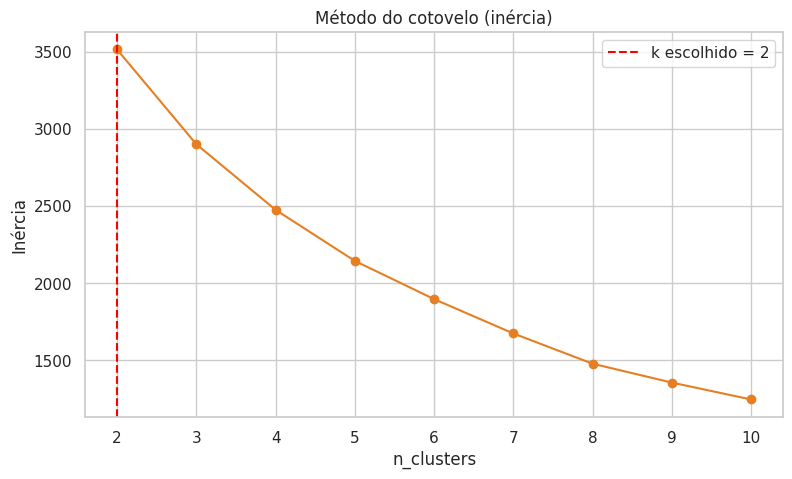

In [12]:
inercias = []
faixa_k = range(2, 11)

for k in faixa_k:
    kmeans_temporario = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans_temporario.fit(dados_transformados)
    inercias.append(kmeans_temporario.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(list(faixa_k), inercias, marker="o", color="#e67e22")
plt.axvline(melhor_k, color="red", linestyle="--", label=f"k escolhido = {melhor_k}")
plt.title("Método do cotovelo (inércia)")
plt.xlabel("n_clusters")
plt.ylabel("Inércia")
plt.xticks(list(faixa_k))
plt.legend()
plt.show()

A curva de inércia desce de forma suave, sem um cotovelo evidente. Isso reforça a leitura
de que não existe um agrupamento óbvio nesses dados além da divisão em dois blocos.

## 4. Pipeline final

Monto o Pipeline completo (`ColumnTransformer` + `KMeans`) com o melhor k encontrado pelo
Optuna. É esse objeto inteiro que vai para o `.pkl` — não o KMeans sozinho — para que o modelo
salvo já saiba padronizar os dados de entrada.

In [13]:
modelo_segmentacao = Pipeline(steps=[
    ("preprocessador", ColumnTransformer([("num", StandardScaler(), FEATURES_CLUSTER)])),
    ("kmeans", KMeans(n_clusters=melhor_k, random_state=RANDOM_STATE, n_init=10)),
])

clusters = modelo_segmentacao.fit_predict(dados_cluster)
dados_cluster["Cluster"] = clusters

dados_pipeline = modelo_segmentacao.named_steps["preprocessador"].transform(
    dados_cluster[FEATURES_CLUSTER])
print(f"Silhouette do pipeline final: {silhouette_score(dados_pipeline, clusters):.4f}")

Silhouette do pipeline final: 0.3048


### 4.1 Perfil dos clusters

In [14]:
perfil_clusters = dados_cluster.groupby("Cluster")[FEATURES_CLUSTER].mean().round(2)
perfil_clusters

,Renda,Investimentos,Score,Probabilidade Inadimplencia,Dívidas
Cluster,,,,,
0,33571.04,630634.14,218.44,44.30,142503.50
1,22154.20,423477.13,43.65,76.25,293819.47


In [15]:
tamanho_clusters = (
    dados_cluster.groupby("Cluster")
    .size()
    .to_frame("quantidade")
    .assign(percentual=lambda t: (t["quantidade"] / len(dados_cluster) * 100).round(1))
)
tamanho_clusters

,quantidade,percentual
Cluster,,
0,298,29.8
1,702,70.2


In [16]:
# junta média das features + tamanho numa tabela só, fica mais fácil de ler
resumo_clusters = perfil_clusters.join(tamanho_clusters)
resumo_clusters

,Renda,Investimentos,Score,Probabilidade Inadimplencia,Dívidas,quantidade,percentual
Cluster,,,,,,,
0,33571.04,630634.14,218.44,44.30,142503.50,298,29.8
1,22154.20,423477.13,43.65,76.25,293819.47,702,70.2


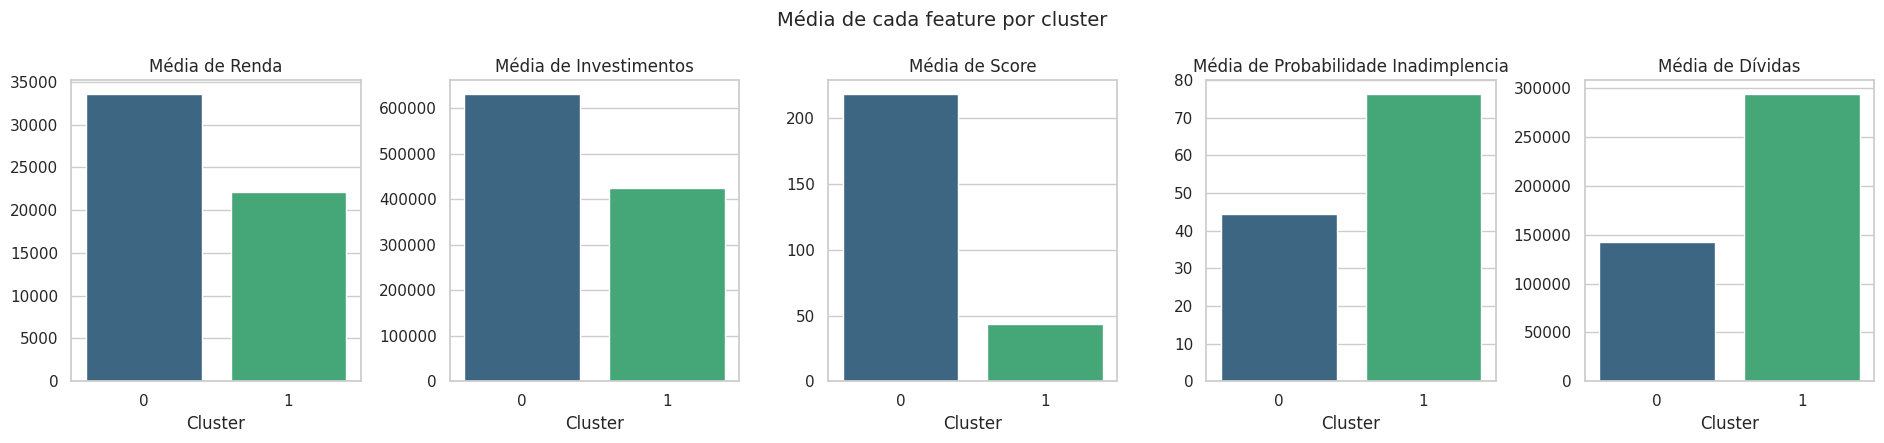

In [17]:
fig, eixos = plt.subplots(1, 5, figsize=(19, 4.5))

for eixo, coluna in zip(eixos, FEATURES_CLUSTER):
    sns.barplot(data=dados_cluster, x="Cluster", y=coluna, hue="Cluster",
                palette="viridis", legend=False, errorbar=None, ax=eixo)
    eixo.set_title(f"Média de {coluna}")
    eixo.set_ylabel("")

plt.suptitle("Média de cada feature por cluster", fontsize=14)
plt.tight_layout()
plt.show()

### 4.2 Nomeando os clusters

In [18]:
nomes_clusters = {
    0: "Bons Pagadores",
    1: "Alto Risco",
}

dados_cluster["Segmento"] = dados_cluster["Cluster"].map(
    lambda cluster: nomes_clusters.get(cluster, f"Cluster {cluster}")
)

dados_cluster.groupby("Segmento")[FEATURES_CLUSTER].mean().round(2)

,Renda,Investimentos,Score,Probabilidade Inadimplencia,Dívidas
Segmento,,,,,
Alto Risco,22154.20,423477.13,43.65,76.25,293819.47
Bons Pagadores,33571.04,630634.14,218.44,44.30,142503.50


### 4.3 Análise complementar: e se a área de marketing quisesse mais grupos?

Dois segmentos é pouco para campanhas direcionadas. Rodei um K-Means com k = 5 só para
enxergar como a base se divide num corte mais fino. **Este modelo não é o que vai para o
`.pkl`** — o que persisto é o do melhor k, seguindo o critério do enunciado.

In [19]:
kmeans_alternativo = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
clusters_alternativos = kmeans_alternativo.fit_predict(dados_transformados)

perfil_alternativo = (
    dados_cluster[FEATURES_CLUSTER]
    .assign(Cluster=clusters_alternativos)
    .groupby("Cluster")
    .agg(["mean"])
    .round(0)
)
perfil_alternativo.columns = FEATURES_CLUSTER
perfil_alternativo["clientes"] = pd.Series(clusters_alternativos).value_counts().sort_index()
print(f"Silhouette com k=5: {silhouette_score(dados_transformados, clusters_alternativos):.4f}")
perfil_alternativo

Silhouette com k=5: 0.2371


,Renda,Investimentos,Score,Probabilidade Inadimplencia,Dívidas,clientes
Cluster,,,,,,
0,37405.0,371052.0,49.0,75.0,385175.0,208
1,17688.0,796982.0,74.0,66.0,279796.0,244
2,36020.0,418517.0,161.0,62.0,112719.0,198
3,12578.0,255538.0,21.0,81.0,252808.0,262
4,34462.0,724434.0,339.0,17.0,133937.0,88


## 5. Extra - visualização dos clusters com PCA 2D

O PCA aqui serve **só para visualizar** os grupos em 2 dimensões. Ele não entra no pipeline
salvo em `modelo_segmentacao.pkl`.

Variância explicada: PC1 = 46.2%, PC2 = 20.8%, total = 67.0%


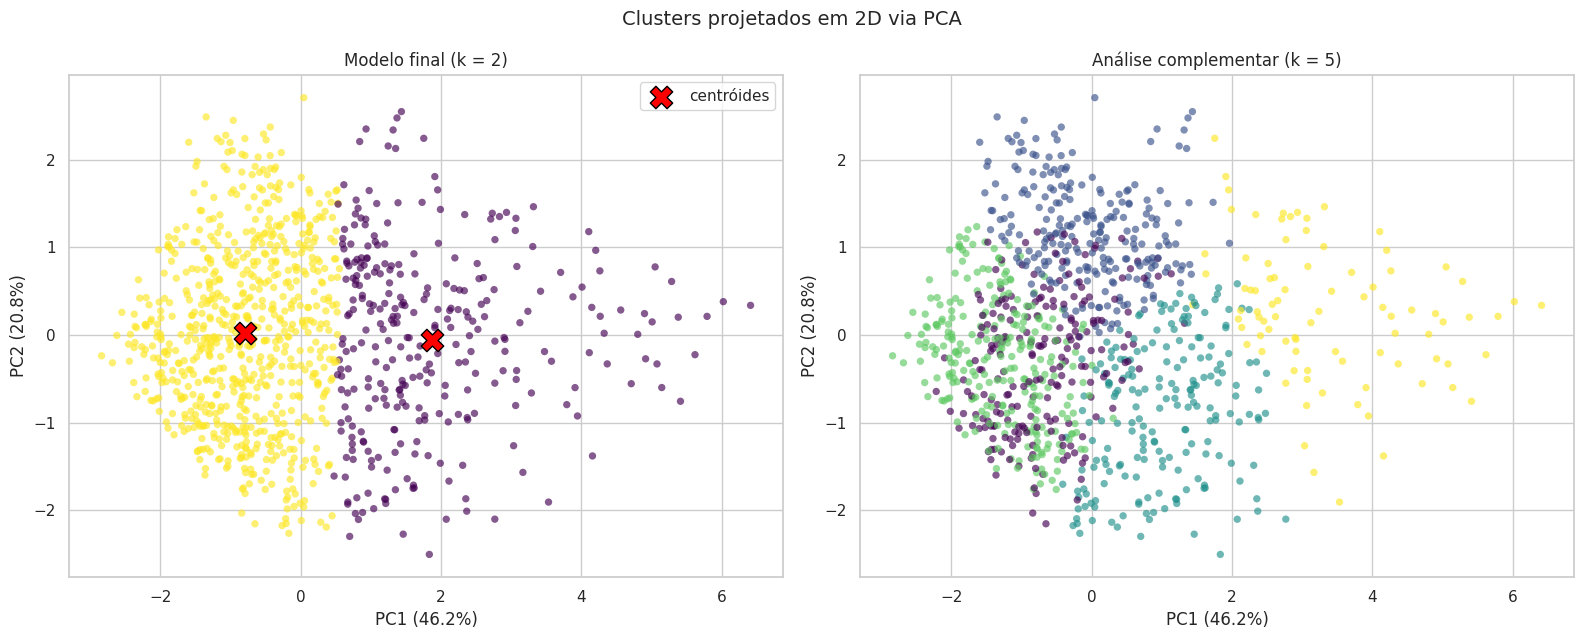

In [20]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
componentes = pca.fit_transform(dados_pipeline)

variancia_explicada = pca.explained_variance_ratio_
print(f"Variância explicada: PC1 = {variancia_explicada[0]:.1%}, "
      f"PC2 = {variancia_explicada[1]:.1%}, total = {variancia_explicada.sum():.1%}")

fig, eixos = plt.subplots(1, 2, figsize=(16, 6.5))

grafico = eixos[0].scatter(componentes[:, 0], componentes[:, 1], c=clusters,
                           cmap="viridis", alpha=0.65, edgecolor="none", s=28)
centroides_pca = pca.transform(modelo_segmentacao.named_steps["kmeans"].cluster_centers_)
eixos[0].scatter(centroides_pca[:, 0], centroides_pca[:, 1], marker="X", s=260,
                 c="red", edgecolor="black", label="centróides")
eixos[0].set_title(f"Modelo final (k = {melhor_k})")
eixos[0].set_xlabel(f"PC1 ({variancia_explicada[0]:.1%})")
eixos[0].set_ylabel(f"PC2 ({variancia_explicada[1]:.1%})")
eixos[0].legend()

eixos[1].scatter(componentes[:, 0], componentes[:, 1], c=clusters_alternativos,
                 cmap="viridis", alpha=0.65, edgecolor="none", s=28)
eixos[1].set_title("Análise complementar (k = 5)")
eixos[1].set_xlabel(f"PC1 ({variancia_explicada[0]:.1%})")
eixos[1].set_ylabel(f"PC2 ({variancia_explicada[1]:.1%})")

plt.suptitle("Clusters projetados em 2D via PCA", fontsize=14)
plt.tight_layout()
plt.show()

No gráfico da esquerda dá para ver claramente os dois blocos separados, com pouca
sobreposição — é isso que o silhouette está capturando. No da direita, com k = 5, os grupos
são cortes dentro desses mesmos blocos e as fronteiras ficam bem mais artificiais.

## 6. Salvando o pipeline

In [21]:
joblib.dump(modelo_segmentacao, "modelo_segmentacao.pkl")
print("Pipeline salvo em modelo_segmentacao.pkl")

modelo_carregado = joblib.load("modelo_segmentacao.pkl")
print("Etapas do pipeline salvo:", list(modelo_carregado.named_steps.keys()))

cliente_novo = pd.DataFrame([{
    "Renda": 42000.0,
    "Investimentos": 800000.0,
    "Score": 480,
    "Probabilidade Inadimplencia": 12.0,
    "Dívidas": 40000.0,
}])
cluster_previsto = modelo_carregado.predict(cliente_novo)[0]
print(f"Cliente de exemplo caiu no cluster {cluster_previsto} "
      f"({nomes_clusters.get(cluster_previsto, 'sem nome')})")

Pipeline salvo em modelo_segmentacao.pkl
Etapas do pipeline salvo: ['preprocessador', 'kmeans']
Cliente de exemplo caiu no cluster 0 (Bons Pagadores)


## 7. Conclusões

**Melhor k e qualidade da segmentação**

O Optuna testou k de 2 a 10 com `GridSampler` e o melhor resultado foi **k = 2**, com
**silhouette ≈ 0,31** — acima da meta de referência de 0,18, mas fora da faixa de k entre 3 e 6
que o enunciado sugeria.

Investiguei esse ponto antes de aceitar o resultado. Testei outras combinações de 5 variáveis
numéricas do dataset (trocando `Probabilidade Inadimplencia` por `Ativos`, por `Idade`, usando
só as notas de preferência de consumo) e o silhouette apontou k = 2 em todas elas. A explicação
está na `Probabilidade Inadimplencia`, que divide a base em dois blocos bem definidos e domina
qualquer corte mais fino. O método do cotovelo confirma: a inércia cai de forma suave, sem
joelho visível.

**Perfil dos dois segmentos** (números exatos na tabela da seção 4.1)

- **Bons Pagadores - 298 clientes (30% da base)** - probabilidade de inadimplência em torno de
  44%, score médio de 218, dívidas de aproximadamente R$ 142 mil, renda média de R$ 33,6 mil e
  R$ 630 mil investidos. É o grupo saudável da carteira: dá para trabalhar aumento de limite,
  oferta de investimentos e crédito com condição melhor.
- **Alto Risco - 702 clientes (70% da base)** - probabilidade de inadimplência de 76%, score
  médio de apenas 44, dívidas de aproximadamente R$ 294 mil, renda média de R$ 22,2 mil e
  R$ 423 mil investidos. Aqui a ação não é vender produto novo, e sim renegociação, controle
  de limite e acompanhamento da carteira.

O que mais chama atenção é que a separação **não é impulsionada pela renda**. O grupo de risco
ganha menos, sim, mas a diferença maior está no nível de dívida (mais que o dobro) e na
probabilidade de inadimplência. Ou seja, o que separa os clientes nesta base é o comportamento
de risco, não o quanto eles ganham — a intuição inicial era de que renda e patrimônio seriam os
grandes separadores, e não foi bem isso.

Também é um resultado desconfortável do ponto de vista de negócio: 70% da carteira caiu no
bloco de risco. Isso diz mais sobre como o dataset foi construído do que sobre uma carteira
real, mas vale o registro.

Na análise complementar com k = 5 (seção 4.3), os subgrupos se organizam principalmente por
nível de dívida e patrimônio investido. Aparece também um grupo pequeno, de 88 clientes, com
score médio de 339 e inadimplência de apenas 17% — um núcleo premium dentro dos bons pagadores,
que o corte em k = 2 não consegue isolar. Se a área de marketing precisar dessa granularidade,
esse seria o caminho, assumindo um silhouette mais baixo (0,24) em troca.

**Observações finais**

- Salvei o **Pipeline completo** (ColumnTransformer + KMeans), não só o KMeans. Se salvasse só
  o KMeans, quem fosse usar o modelo teria que lembrar de padronizar os dados com exatamente a
  mesma média e desvio padrão do treino, o que é uma fonte enorme de erro.
- O K-Means assume clusters aproximadamente esféricos e de tamanho parecido, o que nem sempre
  se sustenta aqui. Um próximo passo seria testar clusterização hierárquica ou DBSCAN e
  comparar os perfis obtidos.